# Qwendean 4B
`qwen3-4B` LoRA fintuned on `iamdyeus/ui-instruct-4k` for UI generation task (production-ready React/TypeScript components with ShadCN UI and Tailwind CSS)

## Wasn't really able to train on `3.5` since it had tokenization issues with my text-only dataset; so fallback to `qwen3-4B`

### Helpful Resources:
- https://unsloth.ai/docs/models/qwen3.5/fine-tune
- https://unsloth.ai/docs/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
- Claude: https://claude.ai/share/53d6ca15-2d5f-4b91-adeb-7105831864d0

### Refrenced Notebooks
- https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(4B)_Vision.ipynb
- https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_MoE.ipynb#scrollTo=tsDf9KDHKgkz

### Installation

In [ ]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
!pip install huggingface_hub
!pip install matplotlib
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0

In [ ]:
# GPU Stats
import torch
import os, re

major_version, minor_version = torch.cuda.get_device_capability()
gpu_stats = torch.cuda.get_device_properties(0)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

print(f"🎮 GPU: {gpu_stats.name}")
print(f"💾 Memory: {max_memory} GB")
print(f"🔧 Compute: {major_version}.{minor_version}")

🎮 GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
💾 Memory: 94.971 GB
🔧 Compute: 12.0


### Authentication
- `drive` - For saving LoRA Adapters (backup)
- `HuggingFaceHub` - For uploading merged & quantized models to huggingface.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive Mounted")

Mounted at /content/drive
Google Drive Mounted


In [ ]:
from huggingface_hub import login, HfApi
login()
api = HfApi()
print(f"Logged in as: {api.whoami()['name']}")

Logged in as: iamdyeus


### Unsloth

In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    "unsloth/Qwen3-4B",
    load_in_4bit = False,
    load_in_16bit = True,
    full_finetuning = False,
    use_gradient_checkpointing = "unsloth", # for long context
    max_seq_length=4096, # Dataset's p99 satisfies at this sequence length
    dtype=None, # Auto-detect (will use BF16 most probably if it's a good gpu lmao)
)

print("\n✅ Model loaded successfully!")
print(f"   Model size: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B parameters")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.7: Fast Qwen3 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-4B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

✅ Model loaded successfully!
   Model size: 4.02B parameters


We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

we use `FastLanguageModel` for configuring rather than `FastVisionModel` since no vision specific work.

the configurations below are optimized for UI generation keeping the dataset small size in mind

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32, # Because the task is CodeGen
    lora_alpha = 32,  # Recommended alpha == r at least; If we kept it 2*r instead; then that would be too aggressive for CodeGen since we're using rsLoRA too
    lora_dropout = 0, # Set to 0 to enable full Unsloth kernel optimization; But yeah we've got no regularization now

    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # Self-attention
        "gate_proj", "up_proj", "down_proj",  # Full MLP for code generation
    ],
    # Attention (q/k/v/o) — learns what to attend to (syntax, structure, context)
    # MLP (gate/up/down) — learns knowledge & patterns (code idioms, APIs, logic)

    bias = "none",
    use_gradient_checkpointing="unsloth",  # Memory efficient training
    random_state = 3407,
    use_rslora = True,  # rank stabilized LoRA
    loftq_config = None, # And LoftQ

)

Unsloth 2026.3.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


### Data Prep
We now use the Qwen 3.5 format for conversation style finetunes. We use the [UI Instruct 4K](https://huggingface.co/datasets/iamdyeus/ui-instruct-4k) dataset for this finetune.

This dataset has `2` splits in 90:10; `train (3.73K rows), validation (416 rows)`

In [ ]:
from datasets import load_dataset
dataset = load_dataset("iamdyeus/ui-instruct-4k")
# dataset["train"] and dataset["validation"] are already separate splits

README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3737 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/416 [00:00<?, ? examples/s]

We now convert the `{prompt,completion}` dataset into conversational format:

In [ ]:
def generate_conversation(examples):
    prompts     = examples["prompt"]
    completions = examples["completion"]
    conversations = []
    for prompt, completion in zip(prompts, completions):
        conversations.append([
            {"role": "user",      "content": prompt},
            {"role": "assistant", "content": completion},
        ])
    return {"conversations": conversations}

dataset = dataset.map(generate_conversation, batched=True)

Map:   0%|          | 0/3737 [00:00<?, ? examples/s]

Map:   0%|          | 0/416 [00:00<?, ? examples/s]

We now have to apply the chat template for `Qwen 3.5` onto the conversations, and save it to `text`.

In [ ]:
def formatting_prompts_func(examples):
    convos = examples["conversations"]
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/3737 [00:00<?, ? examples/s]

Map:   0%|          | 0/416 [00:00<?, ? examples/s]

Let's see how the chat template did!

In [ ]:
dataset["train"][100]['text']

'<|im_start|>user\nCreate a about section for a company website that tells the organization\'s story through a compelling narrative layout, featuring a prominent "Our story" heading in a large font size alongside introductory text, followed by a full-width team image, and concluding with a detailed section that includes the company philosophy in a bold statement, supporting description text, and a team member profile with an avatar, name, and role, all structured using a responsive grid that adapts from stacked mobile layout to multi-column desktop design, built with React, TypeScript, ShadCN UI components, and styled with Tailwind CSS for a clean, professional aesthetic.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nimport React from "react";\n\nconst About = () => {\n  return (\n    <section className="py-32">\n      <div className="container space-y-10 lg:space-y-20">\n        <div className="w-full grid-cols-6 gap-10 space-y-5 lg:grid lg:space-y-0">\n          <h1 classN

### Train the Model

configure `SFTConfig` / training arguments

In [ ]:
from trl import SFTConfig
training_args = SFTConfig(

    # Batch Sizes
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 8, # Effective Batch Size-> 2 x 8: 16
    per_device_eval_batch_size = 2,

    # Durations
    num_train_epochs = 3,
    max_steps = -1,

    # Learning rates
    learning_rate = 1e-4,
    lr_scheduler_type = "linear",
    warmup_steps = 16,

    # Optimizers
    optim = "adamw_8bit",
    weight_decay = 0.01, # gentle, standard regularization

    # Data loading
    dataloader_num_workers=4,  # Parallel data loading
    dataloader_pin_memory=True,  # Faster GPU transfers, though less impactful on Colab since the GPU is already tightly coupled

    # Logging
    logging_steps = 5,
    eval_strategy = "steps",
    eval_steps = 50,

    # Checkpointing
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end = True,   # required for EarlyStopping
    metric_for_best_model = "eval_loss",
    greater_is_better=False,

    # Misc
    seed = 3407,
    max_seq_length=4096, # optimized for the dataset
    report_to = "none", # Use TrackIO/WandB etc
    packing = False,  # bins short samples into max_seq_length, kills padding waste but it can truncate mid-code and feed the model corrupted partial completions as training targets
    output_dir="./qwendean-4b",
    dataset_text_field = "text",
    remove_unused_columns=False

)

configure `SFTTrainer`:

In [ ]:
from trl import SFTTrainer
from transformers import EarlyStoppingCallback

trainer = SFTTrainer(
    model = model,
    args = training_args,
    tokenizer = tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/3737 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/416 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [ ]:
# Compilation can take 2-3 minutes of time, so please be patient :)
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,737 | Num Epochs = 3 | Total steps = 702
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 66,060,288 of 4,088,528,384 (1.62% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,0.658185,0.654105
100,0.583726,0.610653
150,0.578311,0.587785
200,0.548261,0.571169
250,0.540849,0.562341
300,0.470158,0.554380
350,0.493843,0.542052
400,0.488023,0.531595
450,0.446680,0.524183
500,0.431165,0.525301


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


### Training Statistics
After training completes, this section gives you two things: a printed summary of the run, and matplotlib charts to visually diagnose how training went.

#### Printed Summary
Covers the high-level numbers: total time, speed, final train loss, and best checkpoint saved. Below that, a step-by-step loss table shows how train and eval loss evolved across training, so you can spot at a glance whether the model was still improving or had plateaued by the end.

In [ ]:
# Training results summary

# 1. Overall stats
metrics = trainer_stats.metrics
print("=" * 60)
print(f"⏱️  Total time     : {metrics['train_runtime']:.1f}s ({metrics['train_runtime']/60:.1f}min)")
print(f"⚡ Speed           : {metrics['train_samples_per_second']:.2f} samples/sec")
print(f"📉 Final train loss: {metrics['train_loss']:.3f}")

# best_model_checkpoint can be None if early stopping fires before any checkpoint saves
_best_ckpt = trainer.state.best_model_checkpoint
print(f"💾 Best checkpoint : {_best_ckpt.split('/')[-1] if _best_ckpt else 'N/A'}")
print("=" * 60)

# ── 2. Clean loss history ──────────────────────────────────────────────────────
# Train entries: {'loss', 'grad_norm', 'learning_rate', 'epoch', 'step'}
# Eval  entries: {'eval_loss', 'eval_runtime', ..., 'epoch', 'step'}  -- no 'loss' key
history = trainer.state.log_history
train_losses, val_losses = [], []

for entry in history:
    step = entry.get('step', 0)
    if 'loss' in entry and 'eval_loss' not in entry:   # train step entry
        train_losses.append((step, entry['loss']))
    if 'eval_loss' in entry:                           # eval entry
        val_losses.append((step, entry['eval_loss']))

# ── 3. Resolve best checkpoint step for BEST marker ───────────────────────────
# trainer.state.best_model_checkpoint path ends in "checkpoint-{step}"
_best_ckpt_step = None
if _best_ckpt:
    try:
        _best_ckpt_step = int(_best_ckpt.split("-")[-1])
    except ValueError:
        pass  # unexpected path format — marker simply won't appear

# ── 4. Print loss progress table (every 5th train step) ───────────────────────
print("\n📊 LOSS PROGRESS (every 5th logged train step)")
print("-" * 60)
print(f"{'Step':>5}  {'Train':>7}  {'Val':>7}  Status")
print("-" * 60)

for step, loss in train_losses[::5]:
    train_str = f"{loss:.3f}"
    val_str   = "—"
    is_best   = False
    for v_step, v_loss in val_losses:
        if abs(v_step - step) <= 5:
            val_str = f"{v_loss:.3f}"
            # Only mark BEST if this eval step IS the best checkpoint step
            if _best_ckpt_step is not None and v_step == _best_ckpt_step:
                is_best = True
            break
    status = "🔥 BEST" if is_best else "→"
    print(f"{step:>5}  {train_str:>7}  {val_str:>7}  {status}")

print("-" * 60)

# ── 5. Convergence summary — relative improvement, not hardcoded threshold ────
if val_losses:
    _first_eval = val_losses[0][1]
    _best_eval  = min(v[1] for v in val_losses)
    _drop       = _first_eval - _best_eval
    _improved   = _drop > 0.05   # meaningful if eval loss dropped by more than 0.05
    print(f"\n✅ CONVERGENCE : {'IMPROVED ✅' if _improved else 'MINIMAL IMPROVEMENT ⚠️'}")
    print(f"   Eval loss   : {_first_eval:.3f} (start) → {_best_eval:.3f} (best)  [Δ {_drop:+.3f}]")
else:
    print("\n⚠️  No eval loss recorded — check evaluation_strategy config.")

print("=" * 60)

⏱️  Total time     : 9040.7s (150.7min)
⚡ Speed           : 1.24 samples/sec
📉 Final train loss: 0.509
💾 Best checkpoint : checkpoint-700

📊 LOSS PROGRESS (every 5th logged train step)
------------------------------------------------------------
 Step    Train      Val  Status
------------------------------------------------------------
    5    1.074        —  →
   30    0.692        —  →
   55    0.626    0.654  →
   80    0.641        —  →
  105    0.655    0.611  →
  130    0.619        —  →
  155    0.588    0.588  →
  180    0.666        —  →
  205    0.572    0.571  →
  230    0.561        —  →
  255    0.544    0.562  →
  280    0.490        —  →
  305    0.486    0.554  →
  330    0.424        —  →
  355    0.455    0.542  →
  380    0.496        —  →
  405    0.492    0.532  →
  430    0.518        —  →
  455    0.595    0.524  →
  480    0.351        —  →
  505    0.366    0.525  →
  530    0.394        —  →
  555    0.373    0.520  →
  580    0.396        —  →
  605    0.39

#### Graphs
Five charts are generated from `trainer.state.log_history`. Here's what to look for in each:

- **Graph 1 — Training Loss vs Steps:**
  Shows how the model's loss on training data decreased over time. A healthy curve slopes
  smoothly downward and gradually flattens toward the end. Watch out for: a completely flat
  line (learning rate likely too low), wild oscillations (learning rate too high), or a
  near-instant drop to zero (high overfitting risk). Vertical dashed lines mark epoch
  boundaries so you can see per-epoch progress.

- **Graph 2 — Evaluation Loss vs Steps** *(most important):*
  This is your primary signal for model quality. A healthy curve trends downward and
  stabilizes — your best checkpoint (marked with a star ★) should appear near the later
  steps. If eval loss goes down and then starts climbing back up, that's overfitting. If it
  never meaningfully drops, the learning rate may be too low or the model isn't learning
  from this data.

- **Graph 3 — Train vs Eval Loss Overlay:**
  Puts both curves on the same axes so you can see the gap between them. Healthy training
  shows eval loss sitting slightly above train loss, with the gap staying small and stable
  throughout. A widening gap — especially eval rising while train keeps falling — is the
  classic overfitting signature. With a dataset of ~3,730 training samples, this is the
  chart to watch most carefully.

- **Graph 4 — Learning Rate Schedule:**
  Shows how the learning rate changed across steps. You should see a short warmup rise at
  the start (~14 steps at warmup_ratio=0.03), followed by a linear decay down toward zero
  by the end of training (~466 steps total). If training became unstable in the early steps,
  check whether the warmup peak was too aggressive.

- **Graph 5 — Gradient Norm vs Steps** *(only appears if logged):*
  Tracks how large the gradients were during training. Stable training shows gradient norms
  that are relatively consistent or gently decreasing. Large spikes indicate instability;
  a norm that collapses to near zero early may mean the model stopped learning.

📌 Minimum eval loss : 0.5109  (step 700)
📌 Final train loss  : 0.3518


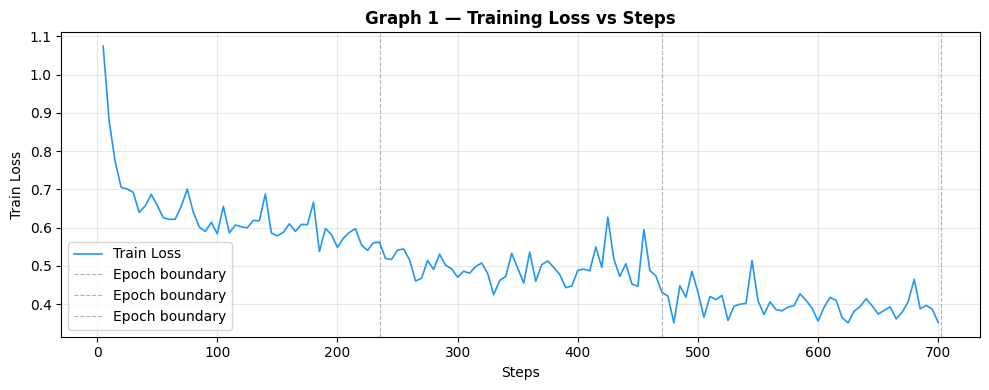

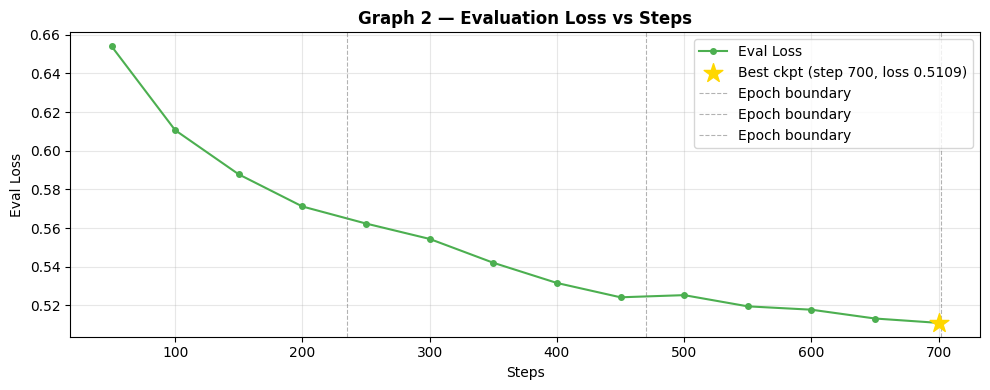

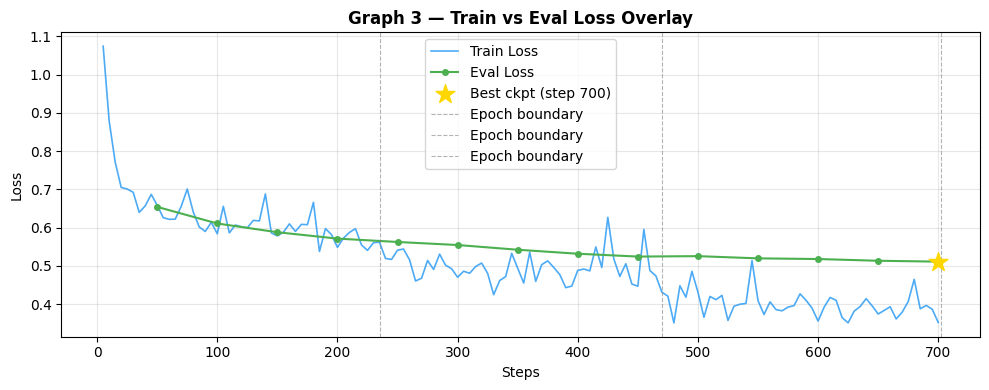

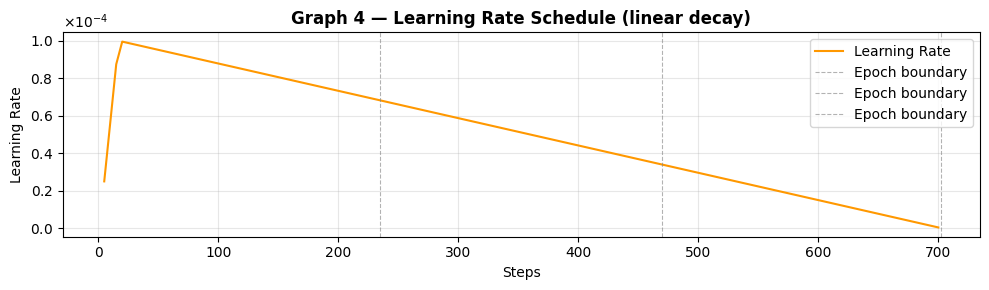

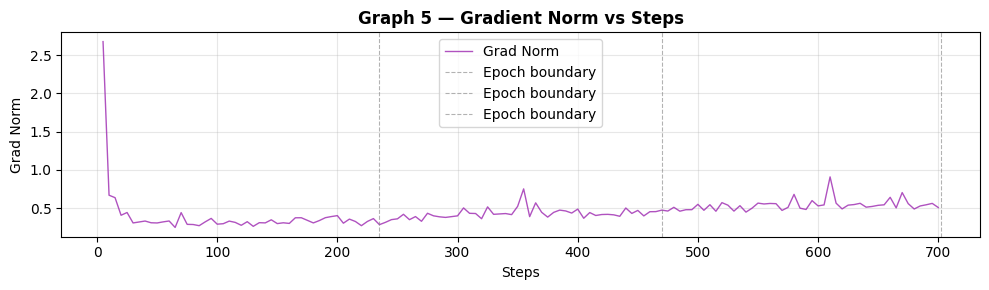

In [ ]:
# Training Visualizations
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Extract all series from log_history ───────────────────────────────────────
# Train entries: {'loss', 'grad_norm', 'learning_rate', 'epoch', 'step'}
# Eval  entries: {'eval_loss', 'eval_runtime', ..., 'epoch', 'step'}  — no 'loss' key
_train_steps, _train_loss_vals = [], []
_eval_steps,  _eval_loss_vals  = [], []
_lr_steps,    _lr_vals         = [], []
_grad_steps,  _grad_vals       = [], []
_epoch_boundaries              = []   # steps where epoch flips

_prev_epoch = None
for entry in trainer.state.log_history:
    step = entry.get("step")
    if step is None:
        continue

    # Detect epoch boundaries from train entries
    epoch = entry.get("epoch")
    if epoch is not None and _prev_epoch is not None:
        if int(epoch) != int(_prev_epoch):
            _epoch_boundaries.append(step)
    if epoch is not None:
        _prev_epoch = epoch

    if "loss" in entry and "eval_loss" not in entry:   # train step entry
        _train_steps.append(step)
        _train_loss_vals.append(entry["loss"])
        if "learning_rate" in entry:
            _lr_steps.append(step)
            _lr_vals.append(entry["learning_rate"])
        if "grad_norm" in entry:
            _grad_steps.append(step)
            _grad_vals.append(entry["grad_norm"])

    if "eval_loss" in entry:                           # eval entry
        _eval_steps.append(step)
        _eval_loss_vals.append(entry["eval_loss"])

# ── Best checkpoint step ───────────────────────────────────────────────────────
_best_step = None
if _eval_loss_vals:
    _min_eval_loss = min(_eval_loss_vals)
    _min_eval_idx  = _eval_loss_vals.index(_min_eval_loss)
    _best_step     = _eval_steps[_min_eval_idx]

# ── Printed stats ──────────────────────────────────────────────────────────────
if _eval_loss_vals:
    print(f"📌 Minimum eval loss : {_min_eval_loss:.4f}  (step {_best_step})")
if _train_loss_vals:
    print(f"📌 Final train loss  : {_train_loss_vals[-1]:.4f}")

# ── Shared style helper ────────────────────────────────────────────────────────
def _add_epoch_lines(ax):
    """Draw vertical dashed lines at epoch boundaries."""
    for eb in _epoch_boundaries:
        ax.axvline(eb, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label=f"Epoch boundary")

# ── Graph 1 : Training Loss vs Steps ──────────────────────────────────────────
if _train_steps:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(_train_steps, _train_loss_vals, color="#2196F3", linewidth=1.2, label="Train Loss")
    _add_epoch_lines(ax)
    ax.set_title("Graph 1 — Training Loss vs Steps", fontweight="bold")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Train Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Graph 2 : Evaluation Loss vs Steps ────────────────────────────────────────
if _eval_steps:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(_eval_steps, _eval_loss_vals, color="#4CAF50", linewidth=1.5,
            marker="o", markersize=4, label="Eval Loss")
    # Mark the best checkpoint with a star
    if _best_step is not None:
        ax.scatter([_best_step], [_min_eval_loss], color="gold", s=200,
                   zorder=5, marker="*", label=f"Best ckpt (step {_best_step}, loss {_min_eval_loss:.4f})")
    _add_epoch_lines(ax)
    ax.set_title("Graph 2 — Evaluation Loss vs Steps", fontweight="bold")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Eval Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Graph 3 : Train vs Eval Loss Overlay ──────────────────────────────────────
if _train_steps and _eval_steps:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(_train_steps, _train_loss_vals, color="#2196F3", linewidth=1.2,
            alpha=0.8, label="Train Loss")
    ax.plot(_eval_steps, _eval_loss_vals, color="#4CAF50", linewidth=1.5,
            marker="o", markersize=4, label="Eval Loss")
    if _best_step is not None:
        ax.scatter([_best_step], [_min_eval_loss], color="gold", s=200,
                   zorder=5, marker="*", label=f"Best ckpt (step {_best_step})")
    _add_epoch_lines(ax)
    ax.set_title("Graph 3 — Train vs Eval Loss Overlay", fontweight="bold")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Graph 4 : Learning Rate Schedule ──────────────────────────────────────────
if _lr_steps:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(_lr_steps, _lr_vals, color="#FF9800", linewidth=1.5, label="Learning Rate")
    _add_epoch_lines(ax)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.set_title("Graph 4 — Learning Rate Schedule (linear decay)", fontweight="bold")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Learning Rate")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Graph 5 (optional) : Gradient Norm vs Steps ───────────────────────────────
if _grad_steps:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(_grad_steps, _grad_vals, color="#9C27B0", linewidth=1.0,
            alpha=0.8, label="Grad Norm")
    _add_epoch_lines(ax)
    ax.set_title("Graph 5 — Gradient Norm vs Steps", fontweight="bold")
    ax.set_xlabel("Steps")
    ax.set_ylabel("Grad Norm")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

### Saving the LoRA adapters to Gdrive

In [ ]:
lora_save_path = "qwendean4k-lora-adapters"

# Saving Locally in the Runtime
model.save_pretrained(lora_save_path)
tokenizer.save_pretrained(lora_save_path)

# Save to Google Drive (backup)
try:
    drive_save_path = "/content/drive/MyDrive/qwendean/v_final"
    model.save_pretrained(drive_save_path)
    tokenizer.save_pretrained(drive_save_path)
    print(f"Backup saved to: {drive_save_path}")
except Exception as e:
    print(f"Could not save to Drive: {e}")
    print(f"(Local copy still available at {lora_save_path}/)")

Backup saved to: /content/drive/MyDrive/qwendean/v_final


### Manual Validation

In [ ]:
FastLanguageModel.for_inference(model)

system_prompt = """You are Qwendean, an expert UI code generation assistant specialized in React, TypeScript, ShadCN UI, and Tailwind CSS.

When given a UI component or section description, you respond with clean, production-ready code inside a single code block.

Rules:
- Always output a single, complete, self-contained component
- Use TypeScript with proper type definitions
- Use ShadCN UI components where appropriate
- Use Tailwind CSS for all styling
- Never include explanations, comments, or text outside the code block"""

user_prompt = "Create a sticky navbar with a logo on the left, centered navigation links that highlight on scroll, and authentication buttons (Login/Signup) on the right, featuring a blur effect on the background when scrolling, using React with TypeScript, ShadCN UI components, and Tailwind CSS."

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user",   "content": user_prompt}
]

encoded = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    add_generation_prompt=True,
    enable_thinking=False
)

if hasattr(encoded, "input_ids"):
    input_ids = encoded.input_ids.to("cuda")
    attention_mask = encoded.attention_mask.to("cuda") if hasattr(encoded, "attention_mask") else torch.ones_like(input_ids)
elif isinstance(encoded, dict):
    input_ids = encoded["input_ids"].to("cuda")
    attention_mask = encoded.get("attention_mask", torch.ones_like(encoded["input_ids"])).to("cuda")
else:
    input_ids = torch.tensor(encoded).unsqueeze(0).to("cuda")
    attention_mask = torch.ones_like(input_ids)

outputs = model.generate(
    input_ids,
    attention_mask=attention_mask,
    max_new_tokens=4096,
    do_sample=True,
    temperature=0.6,
    top_p=0.95,
    top_k=20,
    min_p=0.1,
    repetition_penalty=1.0,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

response = tokenizer.decode(
    outputs[0][input_ids.shape[1]:],
    skip_special_tokens=True
)

print(response)

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, 

"use client";
import { motion } from "framer-motion";
import { Button } from "@/components/ui/button";
import { cn } from "@/lib/utils";

interface NavbarProps {
  logo: {
    url: string;
    src: string;
    alt: string;
    title: string;
  };
  links: {
    name: string;
    url: string;
  }[];
}

const Navbar = ({
  logo = {
    url: "https://www.example.com",
    src: "/placeholder.svg",
    alt: "logo",
    title: "example.com",
  },
  links = [
    { name: "Home", url: "#" },
    { name: "Features", url: "#" },
    { name: "Pricing", url: "#" },
    { name: "About", url: "#" },
  ],
}: NavbarProps) => {
  return (
    <motion.nav
      initial={{ y: -100 }}
      animate={{ y: 0 }}
      transition={{ duration: 0.5 }}
      className="fixed top-0 left-0 right-0 z-50 backdrop-blur-lg bg-background/80"
    >
      <div className="container mx-auto px-4 sm:px-6 lg:px-8">
        <div className="flex items-center justify-between h-16">
          <a href={logo.url} className="flex i

### Publishing the Model on HF for vLLM

In [ ]:
import os
HF_TOKEN = os.environ.get("HF_TOKEN")  # since we've already did login() this should be there by default

In [ ]:
# Main model repo — merged 16bit, ready for vLLM/transformers
model.push_to_hub_merged(
    "iamdyeus/qwendean-4b",
    tokenizer,
    save_method="merged_16bit",
    token=HF_TOKEN,
)

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...wendean-4b/tokenizer.json:   0%|          | 28.8kB / 11.4MB            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0002-of-00002.safetensors:   0%|          | 4.22MB / 3.08GB            


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:10<00:00, 65.34s/it]


Unsloth: Merge process complete. Saved to `/content/iamdyeus/qwendean-4b`


In [ ]:
# GGUF repo — for Ollama/LM Studio users
model.push_to_hub_gguf(
    "iamdyeus/qwendean-4b-GGUF",
    tokenizer,
    quantization_method=["q4_k_m", "q8_0", "q5_k_m"],
    token=HF_TOKEN,
)

Unsloth: Converting model to GGUF format...
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...



Unsloth: Copying 2 files from cache to `/tmp/unsloth_gguf_bluv5j5k`:   0%|          | 0/2 [00:00<?, ?it/s]
Unsloth: Copying 2 files from cache to `/tmp/unsloth_gguf_bluv5j5k`:  50%|█████     | 1/2 [00:06<00:06,  6.12s/it]
Unsloth: Copying 2 files from cache to `/tmp/unsloth_gguf_bluv5j5k`: 100%|██████████| 2/2 [00:17<00:00,  8.76s/it]


Successfully copied all 2 files from cache to `/tmp/unsloth_gguf_bluv5j5k`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

No files have been modified since last commit. Skipping to prevent empty commit.


Uploading Ollama Modelfile...


No files have been modified since last commit. Skipping to prevent empty commit.


Unsloth: Successfully uploaded GGUF to https://huggingface.co/iamdyeus/qwendean-4b-GGUF
Unsloth: Cleaning up temporary files...


'iamdyeus/qwendean-4b-GGUF'